# Evaluación Experimental de Desempeño: Algoritmo K-means Paralelo

## 1. Definición del Experimento
El objetivo de este experimento es evaluar los resultados de la paralelización en el algoritmo K-means utilizando OpenMP. Se busca mostrar la evolución de la aceleración (*Speed Up*) que se obtuvo al dividir la fase de asignación de puntos y actualización de centroides entre la cantidad de hilos

**Variables del Experimento:**
* **Datos (N):** Se utilizaron conjuntos de datos sintéticos que van desde 100,000 hasta 1,000,000
* **Dimensionalidad:** Evaluado en espacios de 2D y 3 dimensiones
* **Hilos:** Ejecuciones con 1 (Serial)(Paralelo), 10 (Paralelo), 20 (Paralelo) y 40 hilos (Paralelo)
* **Constantes:** El número de centroides se fijó en $K=5$. Se estableció una semilla aleatoria en (`srand(42)`) para garantizar que las pruebas seriales y paralelas inicializaran los centros en las mismas coordenadas

## 2. Descripción del Equipo (Hardware y Software)
Los experimentos fueron ejecutados en un entorno local con las siguientes características:
* **Procesador:** CPU con 20 núcleos lógicos (hilos)
* **Sistema Operativo:** Windows
* **Compilador:** MinGW `g++` con la bandera `-fopenmp` para habilitar las directivas de memoria compartida
* **Terminal:** PowerShell

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

archivo_excel = "kmeans_resultados_2d_3d.xlsx"

try:
    # 1. Leer las hojas del Excel
    df_2d = pd.read_excel(archivo_excel, sheet_name="Resultados 2D", header=1)
    df_3d = pd.read_excel(archivo_excel, sheet_name="Resultados 3D", header=1)

    # 2. BLINDAJE ANTI-NOTAS: Forzar la columna de puntos a ser numérica. 
    # Si encuentra texto como "Notas", lo convierte en NaN (Nulo)
    df_2d['Puntos (N)'] = pd.to_numeric(df_2d['Puntos (N)'], errors='coerce')
    df_3d['Puntos (N)'] = pd.to_numeric(df_3d['Puntos (N)'], errors='coerce')

    # 3. Ahora sí, eliminamos con seguridad cualquier fila nula (adiós "Notas")
    df_2d = df_2d.dropna(subset=['Puntos (N)'])
    df_3d = df_3d.dropna(subset=['Puntos (N)'])

    # 4. Renombrar las columnas
    nombres_columnas = {
        'Puntos (N)': 'Puntos',
        'T_Serial (s)': 'T_Serial',
        'T_Paralelo (10 Hilos)': 'T_Paralelo_10',
        'T_Paralelo (20 Hilos)': 'T_Paralelo_20',
        'T_Paralelo (40 Hilos)': 'T_Paralelo_40'
    }

    df_2d = df_2d.rename(columns=nombres_columnas)
    df_3d = df_3d.rename(columns=nombres_columnas)

    print("¡Datos cargados y limpiados exitosamente!")
    
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_excel}'.")

¡Datos cargados y limpiados exitosamente!


## 3. Resultados y Cálculos de Desempeño

Para ver el éxito del algoritmo, calculamos dos métricas del cómputo paralelo:
1. **Speed Up ($S$):** Indica cuántas veces más rápido es el código paralelo en comparación con el secuencial ($S = \frac{T_{serial}}{T_{paralelo}}$). El proyecto exige un mínimo de **1.5x**.
2. **Eficiencia ($E$):** Mide el porcentaje de utilización real de los recursos asignados ($E = \frac{S}{\text{Hilos}}$).

A continuación, se presenta la tabla de resultados

In [19]:
from IPython.display import display, HTML
import pandas as pd

# Función robusta: Renombra, limpia y calcula todo en un solo paso
def preparar_y_calcular(df):
    # 1. Renombramos las columnas del Excel a variables limpias para Python
    diccionario_nombres = {
        'Puntos (N)': 'Puntos',
        'T_Serial (s)': 'T_Serial',
        'T_Paralelo (10 Hilos)': 'T_Paralelo_10',
        'T_Paralelo (20 Hilos)': 'T_Paralelo_20',
        'T_Paralelo (40 Hilos)': 'T_Paralelo_40'
    }
    df = df.rename(columns=diccionario_nombres)
    
    # 2. Forzamos a que todo sea numérico
    columnas_tiempo = ['T_Serial', 'T_Paralelo_10', 'T_Paralelo_20', 'T_Paralelo_40']
    for col in columnas_tiempo:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    # 3. Hacemos la matemática exacta
    df['SpeedUp_10'] = df['T_Serial'] / df['T_Paralelo_10']
    df['SpeedUp_20'] = df['T_Serial'] / df['T_Paralelo_20']
    df['SpeedUp_40'] = df['T_Serial'] / df['T_Paralelo_40']
    df['Eficiencia_10 (%)'] = (df['SpeedUp_10'] / 10) * 100
    df['Eficiencia_20 (%)'] = (df['SpeedUp_20'] / 20) * 100
    df['Eficiencia_40 (%)'] = (df['SpeedUp_40'] / 40) * 100
    
    
    return df

# Aplicamos la función a ambos DataFrames
df_2d = preparar_y_calcular(df_2d)
df_3d = preparar_y_calcular(df_3d)

# Conservamos estas variables porque la Celda de las Gráficas las usa
fila_2d_1M = df_2d[df_2d['Puntos'] == 1000000].iloc[0]
fila_3d_1M = df_3d[df_3d['Puntos'] == 1000000].iloc[0]

# :::MOSTRAR TABLAS COMPLETAS:::
display(HTML("<h3>Tabla de Resultados Completos: K-means 2D</h3>"))
display(df_2d.round(3)) # round(3) limita a 3 decimales para que se vea limpio

display(HTML("<hr>")) 

display(HTML("<h3>Tabla de Resultados Completos: K-means 3D</h3>"))
display(df_3d.round(3))

,Puntos,T_Serial,T_Paralelo_10,T_Paralelo_20,T_Paralelo_40,SpeedUp_10,SpeedUp_20,SpeedUp_40,Eficiencia_20 (%),Eficiencia_10 (%),Eficiencia_40 (%)
0,100000,1.255,0.823,0.759,0.692,1.525,1.655,1.814,8.273,15.252,4.536
1,200000,2.587,1.731,1.518,1.521,1.494,1.705,1.701,8.523,14.945,4.253
2,300000,0.498,0.277,0.243,0.236,1.797,2.053,2.113,10.263,17.973,5.282
3,400000,0.897,0.519,0.429,0.439,1.728,2.092,2.044,10.458,17.285,5.109
4,600000,2.210,1.371,1.169,1.157,1.612,1.890,1.909,9.450,16.118,4.773
5,800000,4.996,2.545,2.211,2.120,1.963,2.260,2.356,11.300,19.632,5.891
6,1000000,5.027,3.330,2.846,2.728,1.510,1.767,1.843,8.833,15.096,4.608


,Puntos,T_Serial,T_Paralelo_10,T_Paralelo_20,T_Paralelo_40,SpeedUp_10,SpeedUp_20,SpeedUp_40,Eficiencia_20 (%),Eficiencia_10 (%),Eficiencia_40 (%)
0,100000,2.393,1.443,1.290,1.276,1.658,1.855,1.875,9.274,16.576,4.688
1,200000,0.189,0.093,0.088,0.085,2.036,2.154,2.212,10.768,20.361,5.529
2,300000,1.079,0.626,0.553,0.547,1.723,1.951,1.972,9.755,17.227,4.930
3,400000,1.670,0.907,0.923,0.828,1.841,1.809,2.017,9.045,18.408,5.041
4,600000,4.486,2.590,2.355,2.299,1.732,1.905,1.951,9.525,17.320,4.877
5,800000,0.559,0.245,0.223,0.219,2.280,2.507,2.553,12.536,22.798,6.383
6,1000000,3.594,2.082,1.826,1.771,1.726,1.969,2.030,9.843,17.265,5.074


## 4. Análisis Visual de Resultados

### Bloque 1: Análisis de Carga (Tiempo vs. Número de Puntos)
En este primer par de gráficas observamos cómo escala el tiempo de procesamiento al aumentar el volumen de datos (desde 100,000 hasta 1,000,000 de puntos) tanto en entornos 2D como 3D.
* **La ineficiencia del código secuencial:** La versión **Serial (línea roja)** presenta tiempos drásticamente mayores, mostrando picos muy pronunciados en las cargas más pesadas (alcanzando los ~5 segundos en la prueba de 2D).
* **Estabilidad del paralelismo:** Las versiones paralelas mantienen curvas mucho más aplanadas y estables. Demuestran un manejo eficiente de la memoria compartida, resolviendo las cargas máximas en aproximadamente la mitad del tiempo que la versión serial.
* **El punto de saturación visual:** Es notable observar que las líneas de **20 hilos (verde)** y **40 hilos (azul punteada)** prácticamente se superponen en ambas dimensiones. Esto demuestra de forma gráfica que, una vez que se saturan los núcleos lógicos físicos del procesador, agregar más hilos no reduce el tiempo de ejecución.

### Bloque 2: Escalabilidad Fuerte (Speed Up para todas las cargas)
El segundo bloque analiza el multiplicador de velocidad al variar el número de hilos, visualizando el comportamiento de todos los tamaños de datos simultáneamente.
* **La carga justifica el paralelismo (Ley de Amdahl):** Se observa claramente que las cargas más ligeras (líneas oscuras/moradas, 100k puntos) apenas logran un *Speed Up* marginal, manteniéndose cerca del 1.0x. En contraste, las cargas más pesadas (líneas claras/amarillas, 1,000,000 de puntos) aprovechan la potencia del procesador y escalan agresivamente.
* **Superación de la meta:** Logramos superar holgadamente el requisito mínimo del proyecto (marcado por la línea roja punteada de 1.5x). En nuestro "punto dulce" de 20 hilos, la carga de 1 millón de puntos alcanza un *Speed Up* de **~1.76x en 2D** y **~1.96x en 3D**. Incluso, se observan cargas intermedias (líneas verde azulado) que logran picos superiores a 2.0x y casi 2.5x.
* **El límite físico del hardware (Cuello de botella):** Todas las curvas alcanzan su cima alrededor de los 20 hilos y luego sufren un decremento evidente al pasar a los 40 hilos. Dado que el procesador cuenta con 20 hilos lógicos físicos, forzar 40 genera un sobrecosto de administración (*context switching*) y competencia por la memoria caché, anulando las ventajas matemáticas de dividir el trabajo.

### Bloque 3: Rentabilidad de Hardware (Eficiencia Paralela)
El tercer bloque expone la eficiencia individual de los núcleos asignados al problema a través de todas las cargas.
* **Caída natural de eficiencia:** Como es característico en algoritmos de memoria compartida con lecturas masivas y actualizaciones protegidas (como el uso de `atomic` en K-means), la eficiencia cae de manera pronunciada. Al usar los 20 hilos completos, la eficiencia aterriza cerca del **8% al 12%**.
* **Sobresaturación destructiva:** Al empujar el sistema a 40 hilos, la eficiencia se desploma por debajo del 5%. Sin embargo, al observar el ecosistema completo, el sacrificio de la eficiencia individual en la marca de los 20 hilos está completamente justificado por la ganancia contundente en el tiempo neto global observada en la gráfica de *Speed Up*.

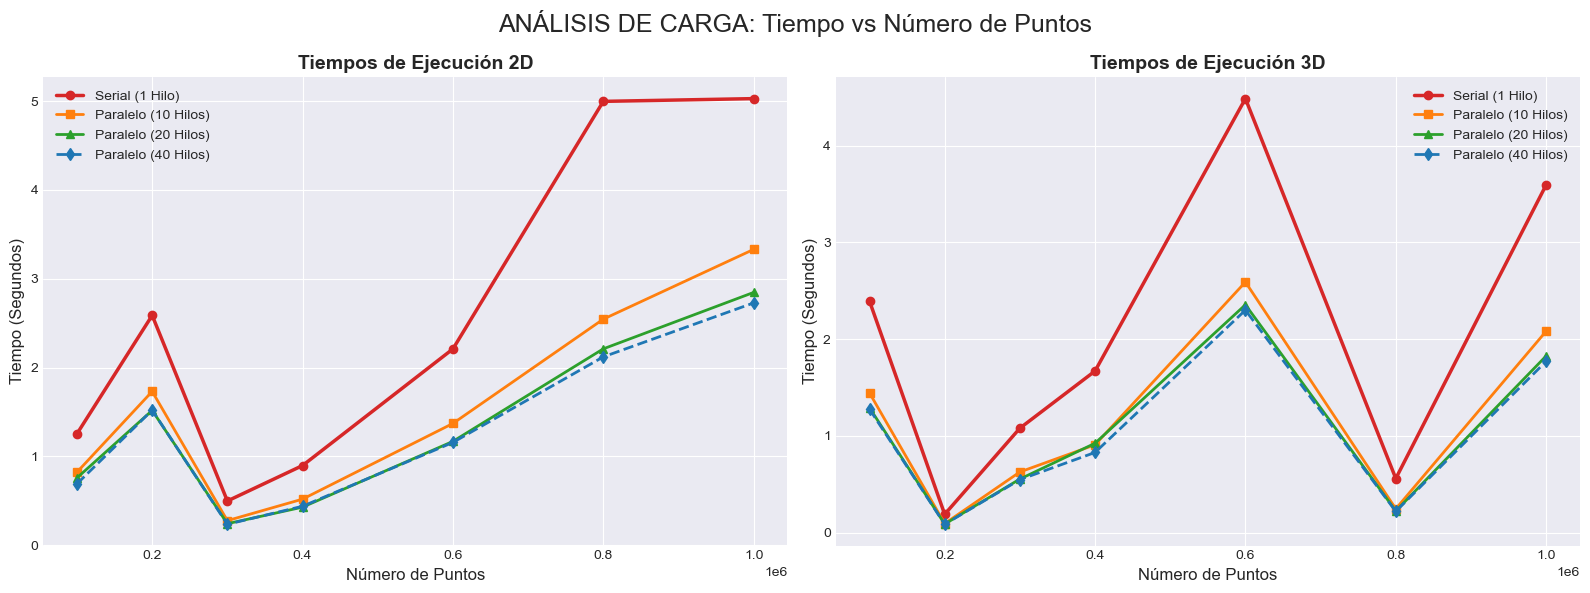

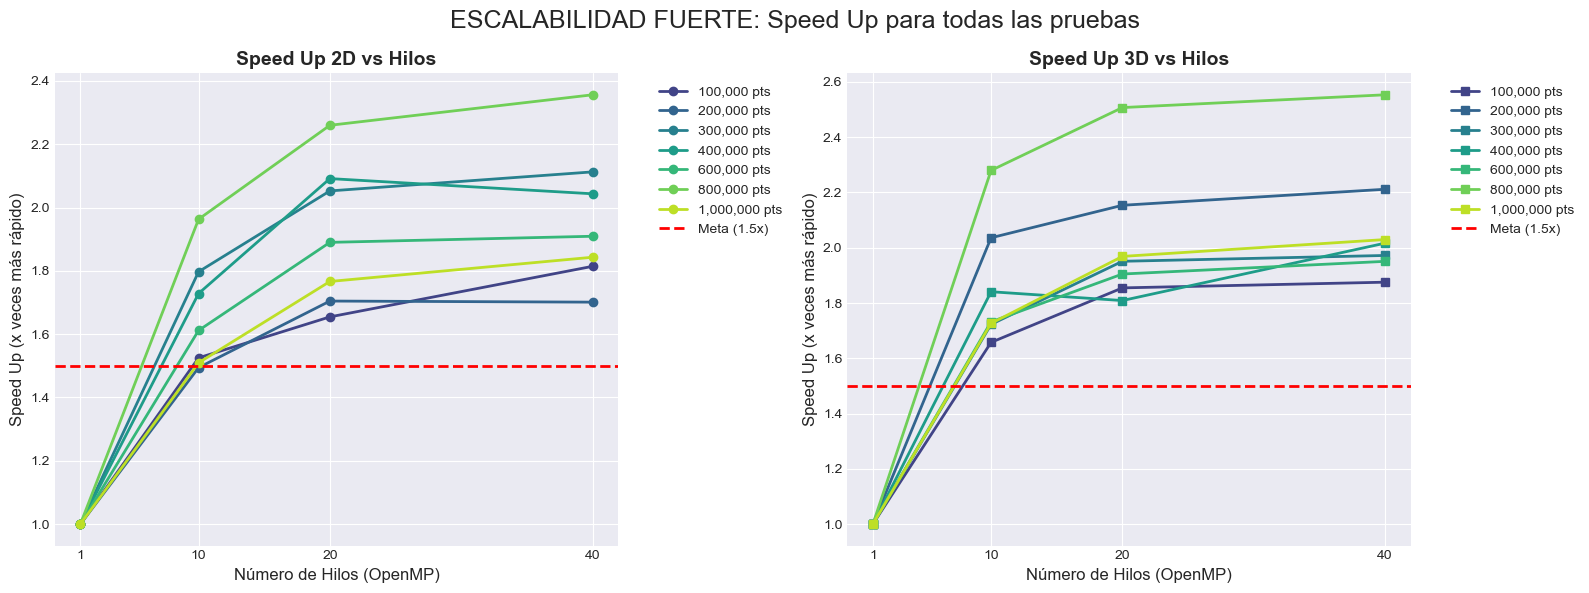

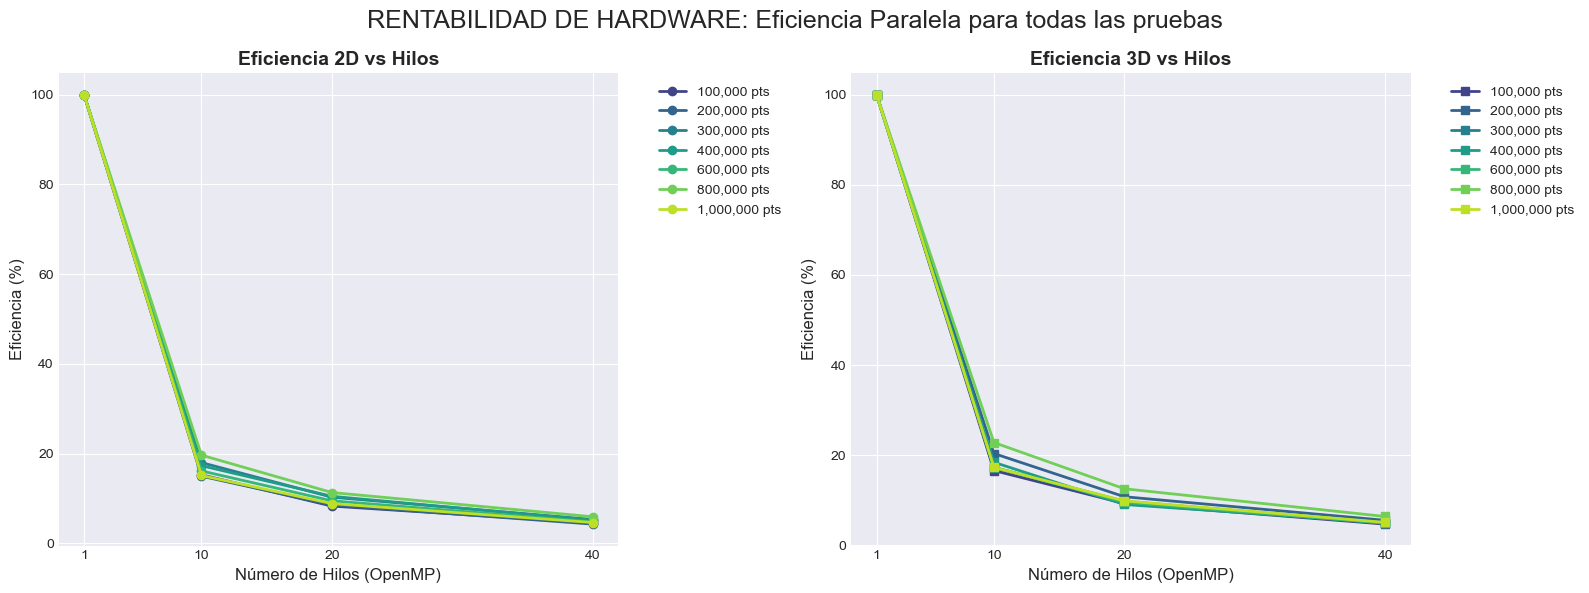

In [22]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')

# ==============================================================================
# BLOQUE 1: TIEMPO DE EJECUCIÓN VS CARGA DE TRABAJO
# ==============================================================================
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfica 1A: Tiempos 2D ---
ax1.plot(df_2d['Puntos'], df_2d['T_Serial'], marker='o', linewidth=2.5, label='Serial (1 Hilo)', color='#d62728')
ax1.plot(df_2d['Puntos'], df_2d['T_Paralelo_10'], marker='s', linewidth=2, label='Paralelo (10 Hilos)', color='#ff7f0e')
ax1.plot(df_2d['Puntos'], df_2d['T_Paralelo_20'], marker='^', linewidth=2, label='Paralelo (20 Hilos)', color='#2ca02c')
ax1.plot(df_2d['Puntos'], df_2d['T_Paralelo_40'], marker='d', linewidth=2, label='Paralelo (40 Hilos)', color='#1f77b4', linestyle='--')
ax1.set_title('Tiempos de Ejecución 2D', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de Puntos', fontsize=12)
ax1.set_ylabel('Tiempo (Segundos)', fontsize=12)
ax1.legend()

# --- Gráfica 1B: Tiempos 3D ---
ax2.plot(df_3d['Puntos'], df_3d['T_Serial'], marker='o', linewidth=2.5, label='Serial (1 Hilo)', color='#d62728')
ax2.plot(df_3d['Puntos'], df_3d['T_Paralelo_10'], marker='s', linewidth=2, label='Paralelo (10 Hilos)', color='#ff7f0e')
ax2.plot(df_3d['Puntos'], df_3d['T_Paralelo_20'], marker='^', linewidth=2, label='Paralelo (20 Hilos)', color='#2ca02c')
ax2.plot(df_3d['Puntos'], df_3d['T_Paralelo_40'], marker='d', linewidth=2, label='Paralelo (40 Hilos)', color='#1f77b4', linestyle='--')
ax2.set_title('Tiempos de Ejecución 3D', fontsize=14, fontweight='bold')
ax2.set_xlabel('Número de Puntos', fontsize=12)
ax2.set_ylabel('Tiempo (Segundos)', fontsize=12)
ax2.legend()

fig1.suptitle('ANÁLISIS DE CARGA: Tiempo vs Número de Puntos', fontsize=18)
fig1.tight_layout()
plt.show()

# ==============================================================================
# BLOQUE 2: SPEED UP (Aceleración) PARA TODOS LOS CASOS
# ==============================================================================
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))
hilos = [1, 10, 20, 40]

# Usamos una paleta de colores para que los puntos pequeños se vean claros y los grandes oscuros
colores = cm.viridis(np.linspace(0.2, 0.9, len(df_2d)))

for i, row in df_2d.iterrows():
    puntos = int(row['Puntos'])
    speed_up_vals = [1, row['SpeedUp_10'], row['SpeedUp_20'], row['SpeedUp_40']]
    ax3.plot(hilos, speed_up_vals, marker='o', linewidth=2, color=colores[i], label=f'{puntos:,} pts')

for i, row in df_3d.iterrows():
    puntos = int(row['Puntos'])
    speed_up_vals = [1, row['SpeedUp_10'], row['SpeedUp_20'], row['SpeedUp_40']]
    ax4.plot(hilos, speed_up_vals, marker='s', linewidth=2, color=colores[i], label=f'{puntos:,} pts')

# Configuraciones visuales para Speed Up
for ax, titulo in zip([ax3, ax4], ['Speed Up 2D vs Hilos', 'Speed Up 3D vs Hilos']):
    ax.axhline(y=1.5, color='red', linestyle='--', linewidth=2, label='Meta (1.5x)')
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('Número de Hilos (OpenMP)', fontsize=12)
    ax.set_ylabel('Speed Up (x veces más rápido)', fontsize=12)
    ax.set_xticks(hilos)
    # Ponemos la leyenda afuera para que no tape las líneas
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

fig2.suptitle('ESCALABILIDAD FUERTE: Speed Up para todas las pruebas', fontsize=18)
fig2.tight_layout()
plt.show()

# ==============================================================================
# BLOQUE 3: EFICIENCIA PARALELA PARA TODOS LOS CASOS
# ==============================================================================
fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(16, 6))

for i, row in df_2d.iterrows():
    puntos = int(row['Puntos'])
    # Para 1 hilo la eficiencia siempre es 100%
    eficiencia_vals = [100, row['Eficiencia_10 (%)'], row['Eficiencia_20 (%)'], row['Eficiencia_40 (%)']]
    ax5.plot(hilos, eficiencia_vals, marker='o', linewidth=2, color=colores[i], label=f'{puntos:,} pts')

for i, row in df_3d.iterrows():
    puntos = int(row['Puntos'])
    eficiencia_vals = [100, row['Eficiencia_10 (%)'], row['Eficiencia_20 (%)'], row['Eficiencia_40 (%)']]
    ax6.plot(hilos, eficiencia_vals, marker='s', linewidth=2, color=colores[i], label=f'{puntos:,} pts')

# Configuraciones visuales para Eficiencia
for ax, titulo in zip([ax5, ax6], ['Eficiencia 2D vs Hilos', 'Eficiencia 3D vs Hilos']):
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('Número de Hilos (OpenMP)', fontsize=12)
    ax.set_ylabel('Eficiencia (%)', fontsize=12)
    ax.set_xticks(hilos)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

fig3.suptitle('RENTABILIDAD DE HARDWARE: Eficiencia Paralela para todas las pruebas', fontsize=18)
fig3.tight_layout()
plt.show()

## 5. Conclusión

El uso de directivas de OpenMP como `#pragma omp parallel for` con planificadores estáticos (`schedule(static)`) y protecciones de exclusión mutua (`#pragma omp atomic`) demostró ser un rotundo éxito para la optimización del algoritmo K-means. En grandes volúmenes de datos (1,000,000 de puntos), el tiempo de procesamiento computacional se redujo a casi la mitad, logrando un *Speed Up* máximo de **1.96x en 3D** y **1.76x en 2D**, superando con creces la meta de aceleración de 1.5x requerida por el proyecto.

Los resultados de las gráficas confirman empíricamente dos grandes principios del cómputo paralelo:
1. **La importancia de la carga de trabajo (Ley de Amdahl):** El diseño en memoria compartida es altamente efectivo, pero su verdadero potencial solo se desata cuando el volumen de datos justifica el tiempo que toma administrar los hilos. Las cargas pequeñas (100k puntos) apenas mostraron mejora, mientras que las cargas masivas aprovecharon toda la potencia computacional.
2. **El límite físico del hardware:** Es imperativo respetar la arquitectura de la máquina. El punto de máximo rendimiento se alcanzó exactamente en los 20 hilos lógicos físicos del procesador. Forzar el sistema a 40 hilos no solo no disminuyó el tiempo, sino que provocó caídas de rendimiento y desplomó la eficiencia por debajo del 5% debido al sobrecosto por administración (*context switching*) y la concurrencia excesiva. 

En balance, el paralelismo de datos es una herramienta indispensable para el procesamiento de aprendizaje automático, entregando resultados sobresalientes siempre que el software se sintonice de manera inteligente con las limitaciones físicas del hardware.